# Notebook: Clasificación HAM10000 con CoAtNet-0

## 1: Instalación de dependencias

In [1]:
# Instalación definitiva y limpieza de conflictos
%pip install -q \
    "tensorflow[and-cuda]==2.16.1" \
    tf-keras==2.16.0 \
    keras-cv==0.9.0 \
    keras-cv-attention-models \
    pandas matplotlib scikit-learn ipywidgets seaborn \
    lime shap opencv-python \
    python-dotenv kaggle \
    optuna optuna-dashboard optuna-integration \
    pydot


# Borramos Keras 3 justo después por si TensorFlow lo ha vuelto a instalar
# %pip uninstall -y keras keras-core

# Hay que instalar manualmente graphviz
# sudo apt install graphviz

# Después tendrás que reiniciar el kernel

Note: you may need to restart the kernel to use updated packages.


In [2]:
# Cargamos las variables de entorno del archivo .env
import os
from dotenv import load_dotenv

# Carga las variables del archivo .env al entorno del sistema
load_dotenv()

True

## 2: Configuración de la GPU y librerías

In [3]:
import os

# 1. Forzamos modo Legacy para CoAtNet
os.environ["TF_USE_LEGACY_KERAS"] = "1"
# 2. Quitamos el aviso de oneDNN (para que el log sea más limpio)
os.environ["TF_ENABLE_ONEDNN_OPTS"] = "0"

os.environ['TF_GPU_ALLOCATOR'] = 'cuda_malloc_async'

# 3. LE INDICAMOS A TENSORFLOW DÓNDE ESTÁN TUS LIBRERÍAS DE NVIDIA
# Buscamos las que instaló el comando [and-cuda] arriba
import site
for path in site.getsitepackages():
    nvidia_path = os.path.join(path, "nvidia/cudnn/lib")
    if os.path.exists(nvidia_path):
        os.environ["LD_LIBRARY_PATH"] = nvidia_path + ":" + os.environ.get("LD_LIBRARY_PATH", "")

# Añadimos la ruta del driver de Windows en WSL2
os.environ["LD_LIBRARY_PATH"] = "/usr/lib/wsl/lib:" + os.environ.get("LD_LIBRARY_PATH", "")

import tensorflow as tf

# Comprobación de la 3080 Ti
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print(f"🔥 ¡CONSEGUIDO! GPU lista: {gpus[0]}")
else:
    print("❌ Seguimos sin ver la GPU. Mira el error de arriba.")

2026-05-07 21:26:57.553360: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-05-07 21:26:58.040818: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


🔥 ¡CONSEGUIDO! GPU lista: PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')


2026-05-07 21:26:58.734490: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:984] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-05-07 21:26:58.805467: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:984] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-05-07 21:26:58.805519: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:984] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.


## 3: Descarga y extracción del Dataset

Nota: debes tener descargado unzip ``sudo apt update && sudo apt install unzip -y``

In [4]:
%%bash
# 1. Definir rutas relativas al proyecto
PROJECT_ROOT=$(pwd)
DATA_DIR="$PROJECT_ROOT/datasets/ham10000"
ZIP_FILE="$DATA_DIR/ham10000-preprocessed.zip"
WITNESS_DIR="$DATA_DIR/organized_ham10000"
META_FILE="$DATA_DIR/HAM10000_metadata.csv"


# 2. Crear la carpeta base si no existe
mkdir -p "$DATA_DIR"

# 3. Lógica para las IMÁGENES (Tu código original)
if [ -d "$WITNESS_DIR" ]; then
    echo "✅ Escenario A: Las carpetas de imágenes ya existen en $WITNESS_DIR. Saltando descarga."
elif [ -f "$ZIP_FILE" ]; then
    echo "📦 Escenario B: ZIP de imágenes encontrado pero no descomprimido. Extrayendo ahora..."
    unzip -q "$ZIP_FILE" -d "$DATA_DIR" && rm "$ZIP_FILE"
    echo "✅ Descompresión terminada y ZIP eliminado."
else
    echo "🌐 Escenario C: No hay imágenes. Iniciando descarga desde Kaggle..."
    curl -L -o "$ZIP_FILE" https://www.kaggle.com/api/v1/datasets/download/rayeedaabir/ham10000-preprocessed
    echo "🚚 Descarga de imágenes finalizada. Descomprimiendo..."
    unzip -q "$ZIP_FILE" -d "$DATA_DIR" && rm "$ZIP_FILE"
fi

# 4. Lógica para los METADATOS (Nueva sección)
if [ -f "$META_FILE" ]; then
    echo "✅ Metadatos encontrados en $META_FILE."
else
    echo "📊 Los metadatos no existen. Descargando HAM10000_metadata.csv desde el dataset original..."
    
    # Descargar solo el archivo CSV del dataset original de kmader
    # Usamos -p para indicar la carpeta de destino
    kaggle datasets download -d kmader/skin-cancer-mnist-ham10000 -f HAM10000_metadata.csv -p "$DATA_DIR"
    
    # Kaggle a veces descarga el archivo individual dentro de un .zip
    if [ -f "$DATA_DIR/HAM10000_metadata.csv.zip" ]; then
        unzip -o "$DATA_DIR/HAM10000_metadata.csv.zip" -d "$DATA_DIR"
        rm "$DATA_DIR/HAM10000_metadata.csv.zip"
    fi
    
    echo "✅ Metadatos listos."
fi

echo "🚀 Proceso completo. Imágenes y metadatos preparados en $DATA_DIR"

✅ Escenario A: Las carpetas de imágenes ya existen en /home/herraiz/proyectos/TFM/datasets/ham10000/organized_ham10000. Saltando descarga.
✅ Metadatos encontrados en /home/herraiz/proyectos/TFM/datasets/ham10000/HAM10000_metadata.csv.
🚀 Proceso completo. Imágenes y metadatos preparados en /home/herraiz/proyectos/TFM/datasets/ham10000


## 4: Preparación de datos (Carga desde directorios)

Primero creamos una función que nos permita traducir las etiquetas, para facilitar su lectura

In [5]:
# Parámetros de configuración
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
DATA_PATH = "datasets/ham10000/organized_ham10000"
META_PATH = "datasets/ham10000/HAM10000_metadata.csv"
AUTOTUNE = tf.data.AUTOTUNE

In [6]:
def get_class_name_es(input_data):
    """
    Traduce las categorías de HAM10000 al español.
    Soporta códigos cortos ('mel') y nombres largos ('Melanoma').
    """
    translations = {
        # Mapeo para nombres largos (los que tienes ahora)
        'actinic keratoses': 'Queratosis actínica',
        'basal cell carcinoma': 'Carcinoma basocelular',
        'benign keratosis': 'Queratosis benigna',
        'dermatofibroma': 'Dermatofibroma',
        'melanocytic nevi': 'Nevus melanocítico',
        'melanoma': 'Melanoma',
        'vascular lesions': 'Lesión vascular',
        
        # Mapeo para códigos cortos (por si acaso)
        'akiec': 'Queratosis actínica',
        'bcc': 'Carcinoma basocelular',
        'bkl': 'Queratosis benigna',
        'df': 'Dermatofibroma',
        'nv': 'Nevus melanocítico',
        'mel': 'Melanoma',
        'vasc': 'Lesión vascular'
    }
    
    def translate(name):
        # Limpiamos el texto: minúsculas y quitar espacios en los extremos
        clean_name = str(name).lower().strip()
        return translations.get(clean_name, name)

    # Si recibimos una lista
    if isinstance(input_data, list):
        return [translate(name) for name in input_data]
    
    # Si recibimos un solo nombre
    return translate(input_data)

Preparamos los metadatos

In [7]:
import pandas as pd
import numpy as np
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# 1. Cargar metadatos
df = pd.read_csv(META_PATH)

#contar valores nulos por columna
print("Valores nulos por columna:")
print(df.isnull().sum())

# 2. Preprocesamiento de Metadatos
# Rellenar edades faltantes con la media
df['age'] = df['age'].fillna(df['age'].mean())

# Encoding: Sexo y Localización (Categorical) + Edad (Escalada)
encoder = OneHotEncoder(sparse_output=False)
cat_features = encoder.fit_transform(df[['sex', 'localization']])
scaler = StandardScaler()
num_features = scaler.fit_transform(df[['age']])

# Combinar todas las características numéricas en un solo array
meta_array = np.hstack([num_features, cat_features]).astype(np.float32)
df_meta_ready = pd.DataFrame(meta_array, index=df['image_id'])

# 3. Mapeo de rutas de archivos
# Buscamos todas las imágenes .jpg en las subcarpetas
all_image_paths = []
all_labels = []
all_meta = []

class_names = sorted(os.listdir(DATA_PATH))  

# Mapeo inverso: Nombre de carpeta -> ID numérico (basado en el orden de class_names)
# 'class_names' viene de tu carpeta: ['Actinic Keratoses', 'Basal Cell Carcinoma', ...]
folder_to_id = {name: i for i, name in enumerate(class_names)}

for folder in class_names:
    folder_path = os.path.join(DATA_PATH, folder)
    for img_name in os.listdir(folder_path):
        if img_name.endswith('.jpg'):
            img_id = img_name.replace('.jpg', '')
            if img_id in df_meta_ready.index:
                all_image_paths.append(os.path.join(folder_path, img_name))
                all_labels.append(folder_to_id[folder])
                all_meta.append(df_meta_ready.loc[img_id].values)

print(f'Todas las etiquetas únicas: {set(all_labels)}')

# ==========================================
# NUEVO: CREACIÓN DEL DATAFRAME PRINCIPAL
# ==========================================
# Creamos el dataframe base con las rutas y etiquetas
data_df = pd.DataFrame({
    'path': all_image_paths,
    'label': all_labels,
    'image_id': [os.path.basename(p).replace('.jpg', '') for p in all_image_paths]
})

# Convertimos la lista de metadatos (all_meta) en un DataFrame y lo concatenamos
# Esto expande los 19 valores de metadatos en columnas individuales
df_meta_values = pd.DataFrame(all_meta)
data_df = pd.concat([data_df, df_meta_values], axis=1)

print(f"✅ DataFrame 'data_df' creado con éxito. Total: {len(data_df)} filas.")

# ==========================================
# 1. DIVISIÓN DEL DATAFRAME (70/15/15)
# ==========================================

# Primero separamos el 15% para el TEST final
train_val_df, test_df = train_test_split(
    data_df, 
    test_size=0.15, 
    random_state=42, 
    stratify=data_df['label']
)

train_df, val_df = train_test_split(
    train_val_df, 
    test_size=0.176, 
    random_state=42, 
    stratify=train_val_df['label']
)

# --- BALANCEO HÍBRIDO A 2000 MUESTRAS ---
TARGET_SAMPLES = 2000

balanced_list = []
for class_idx in range(len(class_names)):
    class_df = train_df[train_df['label'] == class_idx]
    
    if len(class_df) > TARGET_SAMPLES:
        # Undersampling para Nevus
        resampled = class_df.sample(TARGET_SAMPLES, random_state=42)
    else:
        # Oversampling para las demás
        resampled = class_df.sample(TARGET_SAMPLES, replace=True, random_state=42)
    balanced_list.append(resampled)

train_df_balanced = pd.concat(balanced_list).sample(frac=1, random_state=42)

# --- 1. Extraer rutas y metadatos del set BALANCEADO (Entrenamiento) ---
# Eliminamos la '_b' para que coincida con el resto del código
train_paths = train_df_balanced['path'].values
train_meta = np.array(train_df_balanced.drop(['path', 'label', 'image_id'], axis=1).values.tolist())
# IMPORTANTE: Pasamos la etiqueta como entero, process_data se encarga del One-Hot
train_labels = train_df_balanced['label'].values 

# --- 2. Extraer rutas y metadatos del set de VALIDACIÓN ---
val_paths = val_df['path'].values
val_meta = np.array(val_df.drop(['path', 'label', 'image_id'], axis=1).values.tolist())
val_labels = val_df['label'].values

# --- 3. Extraer rutas y metadatos del set de TEST ---
test_paths = test_df['path'].values
test_meta = np.array(test_df.drop(['path', 'label', 'image_id'], axis=1).values.tolist())
test_labels = test_df['label'].values

print(f"📊 Reparto final: Train balanceado ({len(train_paths)}), Val ({len(val_paths)}), Test ({len(test_paths)})")

# ==========================================
# 3. FUNCIÓN DE PROCESAMIENTO (HÍBRIDA)
# ==========================================

def process_data(image_path, metadata, label):
    img = tf.io.read_file(image_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.cast(img, tf.float32) / 255.0
    # Aquí es donde el entero se convierte en vector de 7 posiciones
    return (img, metadata), tf.one_hot(label, depth=7)

# ==========================================
# 4. CREACIÓN DE TF.DATA DATASETS
# ==========================================

# Dataset de Entrenamiento (Quitamos .cache() por seguridad de RAM)
train_ds = tf.data.Dataset.from_tensor_slices((train_paths, train_meta, train_labels))
train_ds = train_ds.shuffle(len(train_paths))
train_ds = train_ds.map(process_data, num_parallel_calls=tf.data.AUTOTUNE)
train_ds = train_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

# Dataset de Validación
val_ds = tf.data.Dataset.from_tensor_slices((val_paths, val_meta, val_labels))
val_ds = val_ds.map(process_data, num_parallel_calls=tf.data.AUTOTUNE)
val_ds = val_ds.batch(BATCH_SIZE).cache().prefetch(tf.data.AUTOTUNE)

# Dataset de Test
test_ds = tf.data.Dataset.from_tensor_slices((test_paths, test_meta, test_labels))
test_ds = test_ds.map(process_data, num_parallel_calls=tf.data.AUTOTUNE)
test_ds = test_ds.batch(BATCH_SIZE).cache().prefetch(tf.data.AUTOTUNE)

print("✅ Datasets creados con éxito y variables sincronizadas.")

Valores nulos por columna:
lesion_id        0
image_id         0
dx               0
dx_type          0
age             57
sex              0
localization     0
dtype: int64
Todas las etiquetas únicas: {0, 1, 2, 3, 4, 5, 6}
✅ DataFrame 'data_df' creado con éxito. Total: 10015 filas.
📊 Reparto final: Train balanceado (14000), Val (1499), Test (1503)
✅ Datasets creados con éxito y variables sincronizadas.


2026-05-07 21:26:59.329925: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:984] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-05-07 21:26:59.330021: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:984] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-05-07 21:26:59.330040: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:984] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-05-07 21:26:59.746629: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:984] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-05-07 21:26:59.746807: I external/local_xla/xla/stream_executor

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10015 entries, 0 to 10014
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   lesion_id     10015 non-null  object 
 1   image_id      10015 non-null  object 
 2   dx            10015 non-null  object 
 3   dx_type       10015 non-null  object 
 4   age           10015 non-null  float64
 5   sex           10015 non-null  object 
 6   localization  10015 non-null  object 
dtypes: float64(1), object(6)
memory usage: 547.8+ KB
                age
count  10015.000000
mean      51.863828
std       16.920252
min        0.000000
25%       40.000000
50%       50.000000
75%       65.000000
max       85.000000


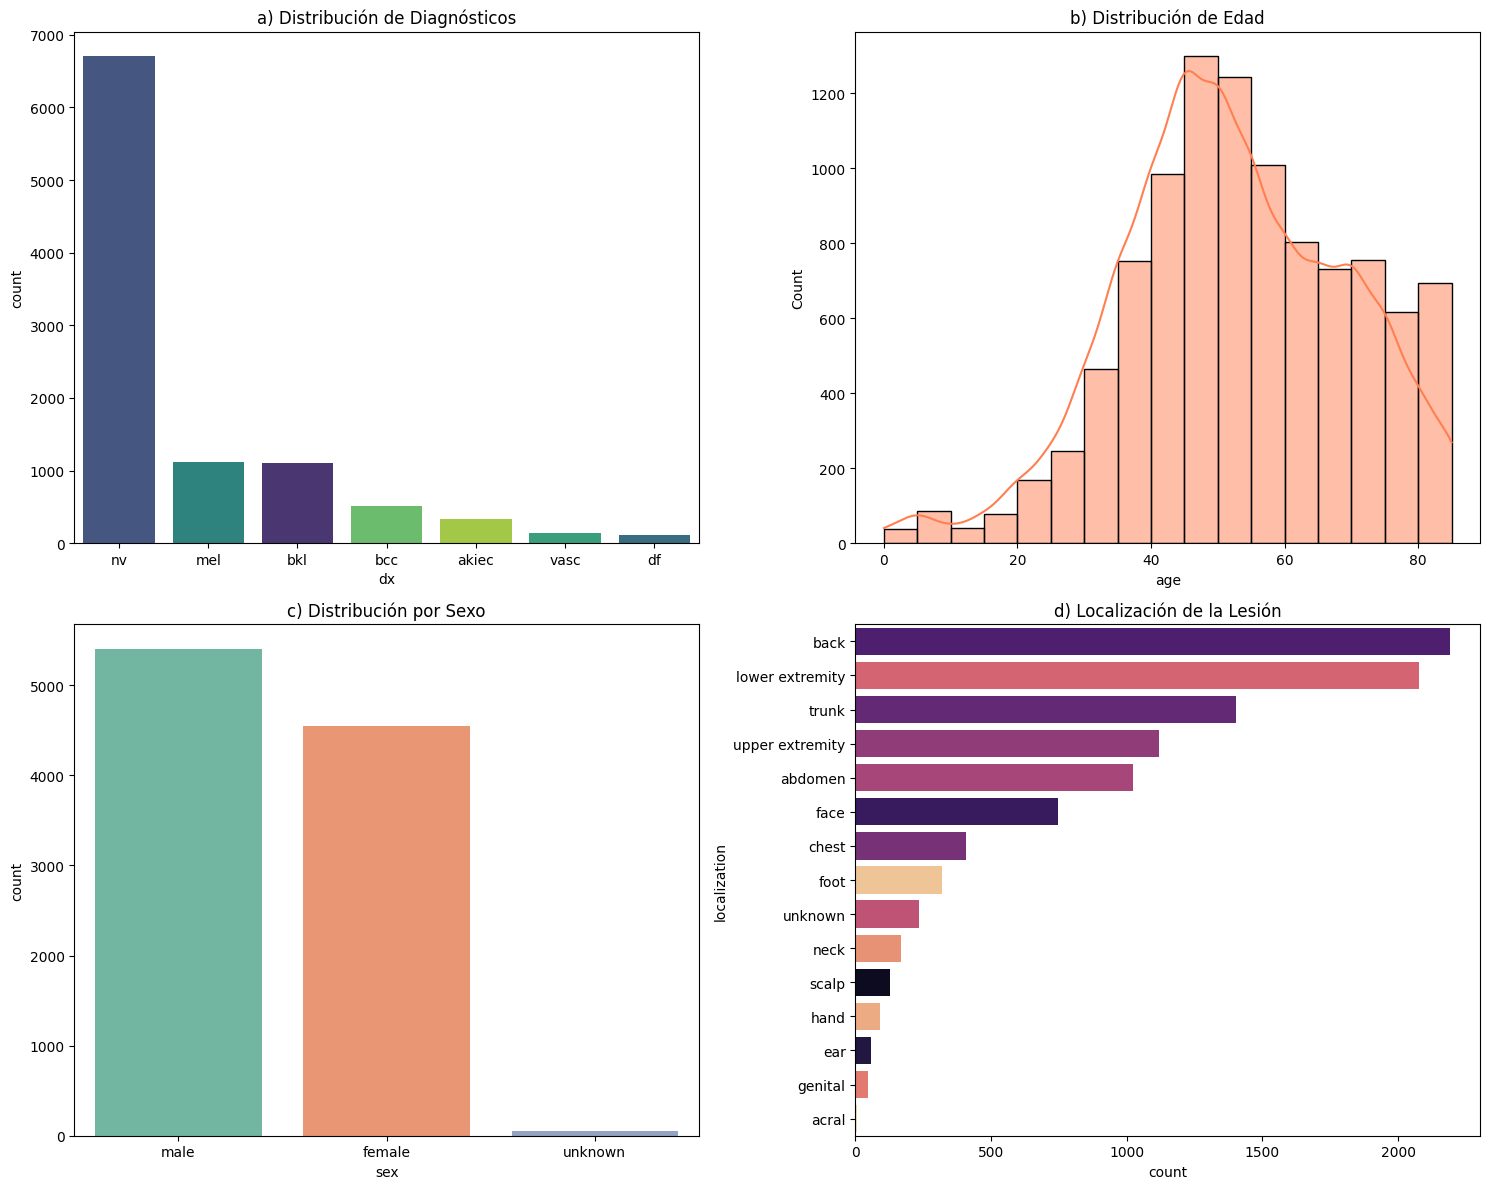

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

df.info()
print(df.describe())

# Preparamos el lienzo
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Gráfico 1: Diagnóstico (Ordenado para ver el desbalance)
# Solución: Añadimos hue='dx' y legend=False
sns.countplot(data=df, x='dx', hue='dx', order=df['dx'].value_counts().index, ax=axes[0, 0], palette='viridis', legend=False)
axes[0, 0].set_title('a) Distribución de Diagnósticos')

# Gráfico 2: Edad
# Este se queda igual, ya que histplot usa un color único ('color') y no una paleta ('palette')
sns.histplot(data=df, x='age', bins=17, kde=True, ax=axes[0, 1], color='coral')
axes[0, 1].set_title('b) Distribución de Edad')

# Gráfico 3: Sexo
# Solución: Añadimos hue='sex' y legend=False
sns.countplot(data=df, x='sex', hue='sex', order=df['sex'].value_counts().index, ax=axes[1, 0], palette='Set2', legend=False)
axes[1, 0].set_title('c) Distribución por Sexo')

# Gráfico 4: Localización
# Solución: Como aquí las barras son horizontales (y='localization'), el hue debe ser igual a 'localization'
sns.countplot(data=df, y='localization', hue='localization', order=df['localization'].value_counts().index, ax=axes[1, 1], palette='magma', legend=False)
axes[1, 1].set_title('d) Localización de la Lesión')

plt.tight_layout()
plt.show()

In [9]:
print("--- 1. RECUENTO DE VALORES ÚNICOS ---")
# nunique() nos dice cuántas opciones distintas hay por cada columna
print(df.nunique())

print("\n--- 2. ¿QUÉ HAY DENTRO DE LAS CATEGORÍAS? ---")
# Para las variables de texto, a veces queremos ver exactamente cuáles son esas opciones
columnas_interes = ['dx', 'dx_type', 'sex']
for col in columnas_interes:
    print(f"\nValores únicos en '{col}':")
    print(df[col].unique())

print("\n--- 3. DUPLICADOS ---")
# Primero, buscamos si hay filas donde ABSOLUTAMENTE TODO sea idéntico
filas_clonadas = df.duplicated().sum()
print(f"Filas 100% duplicadas (errores de registro): {filas_clonadas}")

# Y ahora, el detalle vital del HAM10000:
# ¿Hay alguna foto repetida? ¿Y cuántas pecas tienen múltiples fotos?
fotos_duplicadas = df['image_id'].duplicated().sum()
lesiones_duplicadas = df['lesion_id'].duplicated().sum()

print(f"Imágenes con el mismo ID (fotos repetidas): {fotos_duplicadas}")
print(f"Lesiones con el mismo ID (misma lesión, varias fotos): {lesiones_duplicadas}")

--- 1. RECUENTO DE VALORES ÚNICOS ---
lesion_id        7470
image_id        10015
dx                  7
dx_type             4
age                19
sex                 3
localization       15
dtype: int64

--- 2. ¿QUÉ HAY DENTRO DE LAS CATEGORÍAS? ---

Valores únicos en 'dx':
['bkl' 'nv' 'df' 'mel' 'vasc' 'bcc' 'akiec']

Valores únicos en 'dx_type':
['histo' 'consensus' 'confocal' 'follow_up']

Valores únicos en 'sex':
['male' 'female' 'unknown']

--- 3. DUPLICADOS ---
Filas 100% duplicadas (errores de registro): 0
Imágenes con el mismo ID (fotos repetidas): 0
Lesiones con el mismo ID (misma lesión, varias fotos): 2545


Creamos la función que leerá tanto la imagen como los metadatos

In [10]:
def process_data(image_path, metadata, label):
    # Procesar imagen
    img = tf.io.read_file(image_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.cast(img, tf.float32) / 255.0
    
    # El modelo esperará un diccionario o una tupla de entradas: (imagen, metadatos)
    return (img, metadata), tf.one_hot(label, depth=7)

# Dataset de Entrenamiento
train_ds = tf.data.Dataset.from_tensor_slices((train_paths, train_meta, train_labels))
train_ds = train_ds.shuffle(len(train_paths))
train_ds = train_ds.map(process_data, num_parallel_calls=AUTOTUNE)
train_ds = train_ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

# Dataset de Validación
val_ds = tf.data.Dataset.from_tensor_slices((val_paths, val_meta, val_labels))
val_ds = val_ds.map(process_data, num_parallel_calls=AUTOTUNE)
val_ds = val_ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

class_names_es = get_class_name_es(class_names)

print(f"✅ Clases detectadas (IDs): {class_names}")
print(f"🇪🇸 Traducción: {class_names_es}")


# Optimización para la GPU (Crucial para no tener cuellos de botella)
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)


✅ Clases detectadas (IDs): ['Actinic Keratoses', 'Basal Cell Carcinoma', 'Benign Keratosis', 'Dermatofibroma', 'Melanocytic Nevi', 'Melanoma', 'Vascular Lesions']
🇪🇸 Traducción: ['Queratosis actínica', 'Carcinoma basocelular', 'Queratosis benigna', 'Dermatofibroma', 'Nevus melanocítico', 'Melanoma', 'Lesión vascular']


## 5: Visualización de muestras

📸 Generando galería de presentación (un ejemplo por clase)...


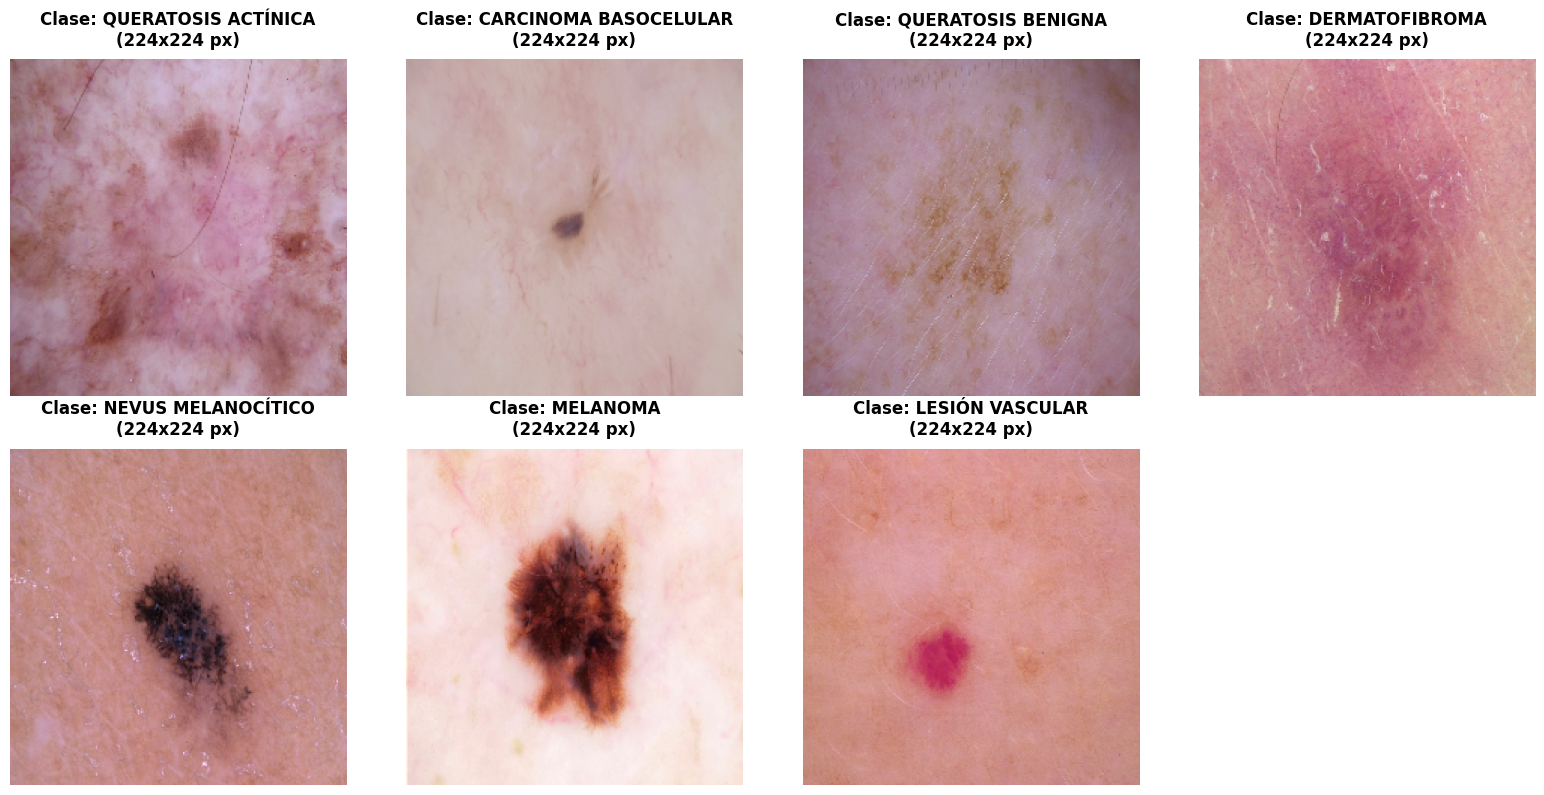

In [11]:
import matplotlib.pyplot as plt

# Configuración de la galería
plt.figure(figsize=(16, 8))
cols = 4
rows = (len(class_names) + cols - 1) // cols

print("📸 Generando galería de presentación (un ejemplo por clase)...")

for i, class_name in enumerate(sorted(class_names)):
    # Ruta a la carpeta de la clase
    class_path = os.path.join(DATA_PATH, class_name)
    # Tomamos la primera imagen que encontremos
    img_name = os.listdir(class_path)[0]
    img_path = os.path.join(class_path, img_name)
    
    # Cargar y procesar imagen para mostrar
    img = tf.keras.utils.load_img(img_path, target_size=IMG_SIZE)
    img_array = tf.keras.utils.img_to_array(img).astype("uint8")
    
    ax = plt.subplot(rows, cols, i + 1)
    plt.imshow(img_array)
    
    # Título elegante con Nombre y Resolución
    plt.title(f"Clase: {get_class_name_es(class_name).upper()}\n({IMG_SIZE[0]}x{IMG_SIZE[1]} px)", 
              fontsize=12, fontweight='bold', pad=10)
    plt.axis("off")

plt.tight_layout()
plt.show()

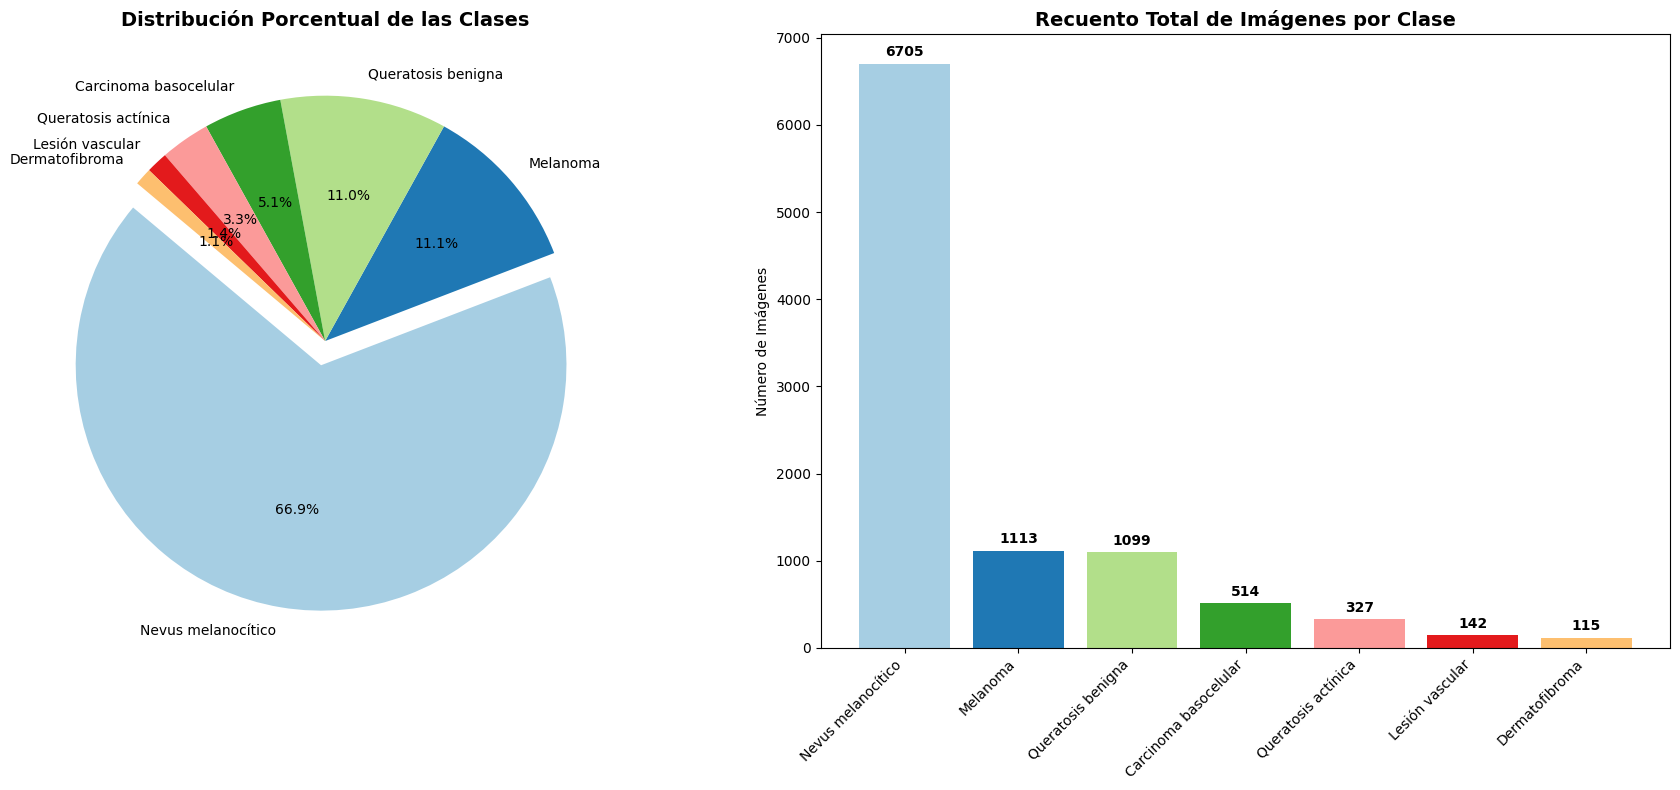


📋 Resumen Estadístico del Dataset (en español):
                 Tipo  Cantidad  Porcentaje
   Nevus melanocítico      6705       66.95
             Melanoma      1113       11.11
   Queratosis benigna      1099       10.97
Carcinoma basocelular       514        5.13
  Queratosis actínica       327        3.27
      Lesión vascular       142        1.42
       Dermatofibroma       115        1.15


In [12]:
# 1. Contar archivos por carpeta
stats = {}
for class_name in class_names:
    class_path = os.path.join(DATA_PATH, class_name)
    stats[class_name] = len(os.listdir(class_path))

# 2. Crear DataFrame y TRADUCIR
df_stats = pd.DataFrame(list(stats.items()), columns=['Tipo', 'Cantidad'])

# --- APLICAMOS LA TRADUCCIÓN AQUÍ ---
df_stats['Tipo'] = df_stats['Tipo'].apply(get_class_name_es)
# ------------------------------------

df_stats = df_stats.sort_values(by='Cantidad', ascending=False)
df_stats['Porcentaje'] = (df_stats['Cantidad'] / df_stats['Cantidad'].sum() * 100).round(2)

# 3. Visualización
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8)) # Aumentado un poco el alto

# Gráfico de Tarta
colors = plt.cm.Paired(range(len(class_names)))
wedges, texts, autotexts = ax1.pie(df_stats['Cantidad'], labels=df_stats['Tipo'], 
                                   autopct='%1.1f%%', startangle=140, colors=colors,
                                   explode=[0.1 if i == 0 else 0 for i in range(len(df_stats))])
ax1.set_title("Distribución Porcentual de las Clases", fontsize=14, fontweight='bold')

# Gráfico de Barras
bars = ax2.bar(df_stats['Tipo'], df_stats['Cantidad'], color=colors)
ax2.set_title("Recuento Total de Imágenes por Clase", fontsize=14, fontweight='bold')
ax2.set_ylabel("Número de Imágenes")

# Rotar etiquetas para que no se solapen los nombres en español
plt.sca(ax2)
plt.xticks(rotation=45, ha='right')

# Añadir etiquetas de cantidad sobre las barras
for bar in bars:
    yval = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2, yval + 50, yval, ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

# Mostrar tabla resumen
print("\n📋 Resumen Estadístico del Dataset (en español):")
print(df_stats.to_string(index=False))

## 6: Pipeline de entrenamiento con CoAtNet-0

In [13]:
from keras_cv_attention_models import coatnet

def build_hybrid_coatnet(img_shape=(224, 224, 3), meta_shape=(27,), dropout_rate=0.3, dense_units=256):
    img_input = tf.keras.Input(shape=img_shape, name="image_input")
    base_vision = coatnet.CoAtNet0(input_shape=img_shape, num_classes=0, pretrained="imagenet")
    x_img = base_vision(img_input)
    x_img = tf.keras.layers.GlobalAveragePooling2D()(x_img)

    meta_input = tf.keras.Input(shape=meta_shape, name="meta_input")
    x_meta = tf.keras.layers.Dense(32, activation='relu')(meta_input)
    x_meta = tf.keras.layers.Dense(16, activation='relu')(x_meta)

    combined = tf.keras.layers.Concatenate()([x_img, x_meta])
    
    # Aquí usamos los parámetros que nos pasa Optuna
    x = tf.keras.layers.Dense(dense_units, activation='relu')(combined)
    x = tf.keras.layers.Dropout(dropout_rate)(x)
    output = tf.keras.layers.Dense(7, activation='softmax')(x)

    return tf.keras.Model(inputs=[img_input, meta_input], outputs=output)

model = build_hybrid_coatnet()
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
              loss='categorical_crossentropy',
              metrics=['accuracy'])
print("✅ Modelo CoAtNet-0 cargado y compilado con éxito.")
model.summary()

>>>> Load pretrained from: /home/herraiz/.keras/models/coatnet0_224_imagenet.h5
✅ Modelo CoAtNet-0 cargado y compilado con éxito.
Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 image_input (InputLayer)    [(None, 224, 224, 3)]        0         []                            
                                                                                                  
 meta_input (InputLayer)     [(None, 27)]                 0         []                            
                                                                                                  
 coatnet0 (Functional)       (None, 7, 7, 768)            2252221   ['image_input[0][0]']         
                                                          8                                       
                                                               

## 7: Entrenamiento

Primero configuramos Optuna como optimizador:

In [14]:
import optuna
storage_name = "sqlite:///optuna_tfm.db"
print(f"✅ Optuna DB lista en {storage_name}")

✅ Optuna DB lista en sqlite:///optuna_tfm.db


In [15]:
from optuna_integration import TFKerasPruningCallback
from tensorflow.keras import layers, models
import keras_cv_attention_models
import gc
import datetime

class TimestampCallback(tf.keras.callbacks.Callback):
    def on_epoch_begin(self, epoch, logs=None):
        hora_actual = datetime.datetime.now().strftime("%H:%M:%S")
        print(f"\n⏰ Inicio Época {epoch + 1}: {hora_actual}")

    def on_epoch_end(self, epoch, logs=None):
        hora_actual = datetime.datetime.now().strftime("%H:%M:%S")
        print(f"✅ Fin Época {epoch + 1}: {hora_actual}")

# Instanciamos el objeto
timestamp_cb = TimestampCallback()

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',          # 'val_loss' suele ser más sensible que 'accuracy'
    patience=8,                  # Dale margen de 8 épocas sin mejora
    restore_best_weights=True,   # CRÍTICO: Al terminar, vuelve a la mejor versión del modelo
    verbose=1
)

import optuna
from optuna.integration import TFKerasPruningCallback

def objective(trial):
    # 1. HIPERPARÁMETROS DE ARQUITECTURA Y OPTIMIZACIÓN
    lr = trial.suggest_float("learning_rate", 1e-5, 5e-4, log=True)
    dropout = trial.suggest_float("dropout", 0.2, 0.5)
    meta_units = trial.suggest_int("meta_units", 32, 128)
    meta_layers = trial.suggest_int("meta_layers", 1, 3)
    
    # 2. HIPERPARÁMETROS DE DATA AUGMENTATION (Tus porcentajes)
    zoom_factor = trial.suggest_float("zoom_factor", 0.0, 0.2)
    contrast_factor = trial.suggest_float("contrast_factor", 0.0, 0.2)
    rotation_prob = trial.suggest_float("rotation_prob", 0.0, 1.0) # Probabilidad de rotar 90º

    # --- Definición de la lógica de Aumento Dinámico ---
    def augment_fn(image):
        # Rotación ortogonal (múltiplos de 90)
        if tf.random.uniform([]) < rotation_prob:
            image = tf.image.rot90(image, k=tf.random.uniform([], 0, 4, tf.int32))
        
        # Contraste y Zoom sutil
        image = tf.image.random_contrast(image, 1.0 - contrast_factor, 1.0 + contrast_factor)
        if zoom_factor > 0:
            crop_size = tf.random.uniform([], 1.0 - zoom_factor, 1.0)
            image = tf.image.central_crop(image, crop_size)
            image = tf.image.resize(image, [224, 224])
        return image

    # 3. PIPELINE DE DATOS CON AUMENTO
    train_ds_aug = tf.data.Dataset.from_tensor_slices((train_paths, train_meta, train_labels))
    train_ds_aug = train_ds_aug.shuffle(2000).map(process_data, num_parallel_calls=tf.data.AUTOTUNE)
    # Aplicamos el aumento al componente de imagen (index 0 de los inputs)
    train_ds_aug = train_ds_aug.map(
        lambda inputs, label: ((augment_fn(inputs[0]), inputs[1]), label),
        num_parallel_calls=tf.data.AUTOTUNE
    ).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

    # 4. CONSTRUCCIÓN DEL MODELO (Híbrido CoAtNet)
    input_img = layers.Input(shape=(224, 224, 3), name="image_input")
    base_model = keras_cv_attention_models.coatnet.CoAtNet0(
        input_shape=(224, 224, 3), num_classes=0, pretrained="imagenet"
    )
    img_features = layers.GlobalAveragePooling2D()(base_model(input_img))

    input_meta = layers.Input(shape=(19,), name="meta_input")
    x_meta = input_meta
    for i in range(meta_layers):
        x_meta = layers.Dense(meta_units, activation="relu")(x_meta)
        x_meta = layers.BatchNormalization()(x_meta)

    combined = layers.Concatenate()([img_features, x_meta])
    x = layers.Dense(256, activation="relu")(combined)
    x = layers.Dropout(dropout)(x)
    output = layers.Dense(7, activation="softmax")(x)

    model = models.Model(inputs=[input_img, input_meta], outputs=output)
    
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )


    # 5. ENTRENAMIENTO (Sin class_weights porque ya está balanceado)
    history = model.fit(
        train_ds_aug,
        validation_data=val_ds, # val_ds se queda original, sin aumentos
        epochs=50, 
        callbacks=[early_stop, TFKerasPruningCallback(trial, "val_accuracy")],
        verbose=0
    )

    return max(history.history["val_accuracy"])

# Lanzar el estudio
study = optuna.create_study(direction="maximize",
                            storage=storage_name,
                            study_name="hybrid_sampling_optimization", 
                            load_if_exists=True
)

[I 2026-05-07 21:27:03,528] Using an existing study with name 'hybrid_sampling_optimization' instead of creating a new one.


Ahora empezamos los trials del entrenamiento. Con el parámetro skip_training a "True" podemos saltarlo y usar el mejor modelo ya entrenado.

In [ ]:
optuna.logging.set_verbosity(optuna.logging.INFO)

# --- CONFIGURACIÓN DE FLUJO ---
SKIP_TRAINING = False     # True: Carga el modelo | False: Entrena
RUN_OPTIMIZATION = True   # True: Busca mejores parámetros | False: Usa los mejores ya encontrados o defaults
TRAIN_FINAL_MODEL = True     # True: Entrena el modelo final con los mejores parámetros | False: Solo carga o entrena sin optimizar
TRIALS = 100                                                                                         

# 1. EJECUCIÓN DE OPTUNA (Solo si no saltamos entrenamiento y queremos optimizar)
if not SKIP_TRAINING and RUN_OPTIMIZATION:
    print(f"🔥 Lanzando optimización con Optuna (n_trials={TRIALS})...")
    study.optimize(objective, n_trials=TRIALS)
    print("✅ Optimización completada.")

# 2. SELECCIÓN DE PARÁMETROS (De la DB de Optuna o Hardcoded)
if len(study.trials) > 0:
    best_params = study.best_params
    print(f"📈 Usando mejores parámetros encontrados por Optuna: {best_params}")
else:
    best_params = {'learning_rate': 1e-4, 'dropout': 0.3, 'dense_units': 256}
    print(f"⚠️ No hay historial en la DB. Usando parámetros por defecto: {best_params}")

🔥 Lanzando optimización con Optuna (n_trials=100)...
>>>> Load pretrained from: /home/herraiz/.keras/models/coatnet0_224_imagenet.h5


2026-05-07 21:27:26.598888: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:465] Loaded cuDNN version 8907
I0000 00:00:1778185649.372767  234551 service.cc:145] XLA service 0x7acc513dfca0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778185649.372821  234551 service.cc:153]   StreamExecutor device (0): NVIDIA GeForce RTX 3080 Ti, Compute Capability 8.6
2026-05-07 21:27:29.377382: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1778185649.469248  234551 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


Epoch 11: early stopping
Restoring model weights from the end of the best epoch: 3.


[I 2026-05-07 21:47:15,846] Trial 14 finished with value: 0.8632421493530273 and parameters: {'learning_rate': 4.4245898771683075e-05, 'dropout': 0.3082996194706007, 'meta_units': 110, 'meta_layers': 1, 'zoom_factor': 0.1334787983023344, 'contrast_factor': 0.0008570164794250157, 'rotation_prob': 0.2418444385738659}. Best is trial 1 with value: 0.8652434945106506.


>>>> Load pretrained from: /home/herraiz/.keras/models/coatnet0_224_imagenet.h5


...

>>>> Load pretrained from: /home/herraiz/.keras/models/coatnet0_224_imagenet.h5


[I 2026-05-08 04:42:55,232] Trial 27 pruned. Trial was pruned at epoch 0.


>>>> Load pretrained from: /home/herraiz/.keras/models/coatnet0_224_imagenet.h5


[I 2026-05-08 05:14:41,451] Trial 28 pruned. Trial was pruned at epoch 0.


>>>> Load pretrained from: /home/herraiz/.keras/models/coatnet0_224_imagenet.h5


### 7.1 Construcción del modelo final

In [ ]:
if TRAIN_FINAL_MODEL:
    # 1. Recuperar los mejores parámetros
    best_params = study.best_params
    print(f"🏆 Mejores parámetros: {best_params}")

    # 2. Reconstruir la arquitectura ganadora
    input_img = layers.Input(shape=(224, 224, 3), name="image_input")
    base_model = keras_cv_attention_models.coatnet.CoAtNet0(
        input_shape=(224, 224, 3), num_classes=0, pretrained="imagenet"
    )
    img_output = base_model(input_img)
    img_features = layers.GlobalAveragePooling2D()(img_output)

    input_meta = layers.Input(shape=(19,), name="meta_input")
    x_meta = input_meta
    for _ in range(best_params['meta_layers']):
        x_meta = layers.Dense(best_params['meta_units'], activation="relu")(x_meta)
        x_meta = layers.BatchNormalization()(x_meta)

    combined = layers.Concatenate()([img_features, x_meta])
    x = layers.Dense(256, activation="relu")(combined)
    x = layers.Dropout(best_params['dropout'])(x)
    output = layers.Dense(7, activation="softmax")(x)

    final_model = models.Model(inputs=[input_img, input_meta], outputs=output)

    # 3. Compilar y entrenar a fondo (puedes subir las epochs aquí)
    final_model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=best_params['learning_rate']),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    checkpoint_path = "models/best_hybrid_model_sampling.h5"
    callbacks = [
        # Para si el modelo deja de mejorar (ahorra tiempo y luz)
        tf.keras.callbacks.EarlyStopping(
            monitor='val_loss', 
            patience=8, 
            restore_best_weights=True
        ),
        # Guarda automáticamente el mejor modelo encontrado
        tf.keras.callbacks.ModelCheckpoint(
            filepath=checkpoint_path,
            monitor='val_accuracy',
            save_best_only=True,
            mode='max',
            verbose=1
        ),
        # Para ver la hora en los logs del servidor
    TimestampCallback()
    ]
    final_model.summary()

    tf.keras.utils.plot_model(
        final_model, 
        to_file='modelo_hibrido.png',
        show_shapes=True, 
        show_layer_names=True,
        rankdir='LR' # 'TB' para vertical, 'LR' para horizontal
    )

    print("🚀 Entrenando el modelo definitivo...")
        # USAMOS train_ds (70%) y val_ds (15%) POR SEPARADO 
        # para que los callbacks tengan sentido.
    final_model.fit(
        train_ds_final_balanced, 
        validation_data=val_ds,
        epochs=50, 
        callbacks=[checkpoint_callback, early_stop]
    )
    final_model.save("modelo_tfm_balanceado.h5")

else:
    # SI NO ENTRENAMOS, CARGAMOS LO QUE YA HAY EN DISCO
    if os.path.exists(MODEL_PATH):
        print(f"📦 Cargando modelo final desde {MODEL_PATH}...")
        final_model = tf.keras.models.load_model(MODEL_PATH)
    else:
        print(f"❌ ERROR: TRAIN_FINAL_MODEL es False pero no encuentro {MODEL_PATH}")

## 8: Predicciones (Preparación de datos)
En esta celda extraemos las etiquetas reales y generamos las predicciones del modelo sobre el set de validación.

In [ ]:
def get_predictions(dataset, name=""):
    print(f"🔮 Generando predicciones sobre el set de {name}...")
    y_true = []
    y_pred = []
    
    # Iteramos sobre el dataset para obtener imágenes, metadatos y etiquetas reales
    for (images, meta), labels in dataset:
        # Predicción del modelo híbrido
        preds = final_model.predict((images, meta), verbose=0)
        
        # Guardamos la realidad (argmax de one-hot) y la predicción
        y_true.extend(np.argmax(labels.numpy(), axis=1))
        y_pred.extend(np.argmax(preds, axis=1))
        
    return np.array(y_true), np.array(y_pred)

if TRAIN_FINAL_MODEL:
    # 1. Generamos las de ENTRENAMIENTO
    y_true_train, y_pred_train = get_predictions(train_ds, name="ENTRENAMIENTO")

    # 2. Generamos las de VALIDACIÓN
    y_true_val, y_pred_val = get_predictions(val_ds, name="VALIDACIÓN")

    # 3. Generamos las de TEST
    y_true_test, y_pred_test = get_predictions(test_ds, name="TEST")

    print(f"✅ Análisis completado. Entrenamiento: {len(y_true_train)} imágenes | Validación: {len(y_true_val)} imágenes | Test: {len(y_true_test)} imágenes.")

## 9: Métricas Globales y por Clase

Aquí verás el rendimiento del entrenamiento (si lo hubo) y el reporte detallado (Precisión, Recall, F1-Score) por cada tipo de lesión.

In [ ]:
from sklearn.metrics import classification_report, accuracy_score

# 1. Accuracy Global
acc_train = accuracy_score(y_true_train, y_pred_train)
acc_val = accuracy_score(y_true_val, y_pred_val)
acc_test = accuracy_score(y_true_test, y_pred_test)

print("="*60)
print(f"📈 RENDIMIENTO GLOBAL (Modelo Híbrido)")
print(f"   - Accuracy Entrenamiento: {acc_train:.4f}")
print(f"   - Accuracy Validación:    {acc_val:.4f}")
print(f"   - Accuracy Test:          {acc_test:.4f}")
print("="*60)

# Reporte detallado test
print("\n📋 REPORTE DETALLADO POR CLASE (SET DE TEST):")
print(classification_report(y_true_test, y_pred_test, target_names=class_names_es))

# 2. Reporte Detallado de Validación
print("\n📋 REPORTE DETALLADO POR CLASE (SET DE VALIDACIÓN):")
print(classification_report(y_true_val, y_pred_val, target_names=class_names_es))

# 3. Reporte Detallado de Entrenamiento
print("\n📋 REPORTE DETALLADO POR CLASE (SET DE ENTRENAMIENTO):")
print(classification_report(y_true_train, y_pred_train, target_names=class_names_es))

## 10: Matriz de Confusión

Esta es la gráfica visual definitiva para ver dónde se "equivoca" el modelo (por ejemplo, si confunde Melanoma con Nevus).

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Calculamos las matrices (la lógica sigue igual)
cm_train = confusion_matrix(y_true_train, y_pred_train)
cm_val = confusion_matrix(y_true_val, y_pred_val)
cm_test = confusion_matrix(y_true_test, y_pred_test)
# 2. Configuramos el gráfico
fig, ax = plt.subplots(1, 3, figsize=(33, 10)) # Aumentamos un poco el tamaño

# Matriz de Entrenamiento (Verde)
sns.heatmap(cm_train, annot=True, fmt='d', cmap='Greens', ax=ax[0],
            xticklabels=class_names_es, yticklabels=class_names_es,
            cbar=False) # Quitamos la barra lateral para ganar espacio
ax[0].set_title('Matriz de Confusión: ENTRENAMIENTO', fontsize=16, fontweight='bold')
ax[0].set_xlabel('Predicción', fontsize=12)
ax[0].set_ylabel('Realidad', fontsize=12)

# Matriz de Validación (Azul)
sns.heatmap(cm_val, annot=True, fmt='d', cmap='Blues', ax=ax[1],
            xticklabels=class_names_es, yticklabels=class_names_es,
            cbar=False)
ax[1].set_title('Matriz de Confusión: VALIDACIÓN', fontsize=16, fontweight='bold')
ax[1].set_xlabel('Predicción', fontsize=12)
ax[1].set_ylabel('Realidad', fontsize=12)

# Matriz de Test (Roja)
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Reds', ax=ax[2],
            xticklabels=class_names_es, yticklabels=class_names_es,
            cbar=False)
ax[2].set_title('Matriz de Confusión: TEST', fontsize=16, fontweight='bold')
ax[2].set_xlabel('Predicción', fontsize=12)
ax[2].set_ylabel('Realidad', fontsize=12)

# --- AJUSTE CRÍTICO DE ETIQUETAS ---
# Rotamos las etiquetas de las X para que no se pisen
for a in ax:
    plt.sca(a)
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

## 11: Inteligencia Artificial Explicable (XAI) - Grad-CAM
En esta sección visualizamos en qué regiones de la imagen se fija el modelo CoAtNet para clasificar las lesiones.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import os
import random
import contextlib
import tensorflow as tf
import shap
import lime
from lime import lime_image
from skimage.segmentation import mark_boundaries, quickshift

# --- 1. FUNCIONES CORE ADAPTADAS ---

def get_gradcam_heatmap(img_input, meta_input, model, last_conv_layer_name, pred_index):
    # Accedemos al backbone dentro del modelo final
    v_model = model.get_layer('coatnet0')
    
    # El grad_model debe salir del modelo COMPLETO para captar el Softmax final
    # Pero necesitamos la salida de la capa conv que está "escondida" dentro de coatnet0
    grad_model = tf.keras.models.Model(
        [model.inputs], 
        [v_model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        # Pasamos imagen Y metadatos
        conv_output, predictions = grad_model([img_input, meta_input])
        class_channel = predictions[:, pred_index]

    # El resto de la lógica de gradientes se mantiene igual
    grads = tape.gradient(class_channel, conv_output)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    heatmap = conv_output[0] @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-10)
    return heatmap.numpy()

def superimpose_heatmap(img_path, heatmap, alpha=0.4):
    img = tf.keras.utils.load_img(img_path)
    img_arr = tf.keras.utils.img_to_array(img)
    heatmap_arr = np.uint8(255 * heatmap)
    jet = plt.get_cmap("jet")(np.arange(256))[:, :3]
    jet_heatmap = tf.keras.utils.array_to_img(jet[heatmap_arr]).resize((img_arr.shape[1], img_arr.shape[0]))
    jet_heatmap = tf.keras.utils.img_to_array(jet_heatmap)
    return tf.keras.utils.array_to_img(jet_heatmap * alpha + img_arr)

# --- 2. CONFIGURACIÓN Y BUCLE PRINCIPAL ---

print("📊 Generando comparativa XAI (Grad-CAM, LIME, SHAP) para el modelo híbrido...")

# Identificar capa convolucional dentro del sub-modelo
sub_model = final_model.get_layer('coatnet0')
last_conv_name = [l.name for l in sub_model.layers if 'conv' in l.name.lower()][-1]
explainer_lime = lime_image.LimeImageExplainer()

n_clases = len(class_names)
fig, axes = plt.subplots(nrows=n_clases, ncols=4, figsize=(22, 5 * n_clases))
col_titles = ['Original', 'Grad-CAM (Zona)', 'LIME (Segmentos)', 'SHAP (Píxeles)']

# Silenciamos la verbosidad de SHAP y LIME
with open(os.devnull, 'w') as f, contextlib.redirect_stdout(f), contextlib.redirect_stderr(f):
    for i, nombre_clase in enumerate(class_names):
        # A. Selección de imagen y metadatos
        class_dir = os.path.join(DATA_PATH, nombre_clase)
        img_name = random.choice(os.listdir(class_dir))
        img_path = os.path.join(class_dir, img_name)
        img_id = img_name.replace('.jpg', '')
        
        # Extraer metadatos reales de esa imagen específica
        current_meta = df_meta_ready.loc[[img_id]].values.astype('float32')
        
        # B. Preparación de imagen
        img_raw = tf.keras.utils.load_img(img_path, target_size=(224, 224))
        img_array = tf.keras.utils.img_to_array(img_raw)
        img_input = np.expand_dims(img_array, axis=0) / 255.0

        # C. WRAPPER PARA LIME/SHAP (Inyecta metadatos fijos en cada batch de perturbaciones)
        def hybrid_predict(batch):
            m_batch = np.repeat(current_meta, batch.shape[0], axis=0)
            return final_model.predict([batch, m_batch], verbose=0)

        # 1. Ejecutar Predicción del modelo completo
        full_pred = final_model.predict([img_input, current_meta], verbose=0)
        pred_idx = np.argmax(full_pred[0])

        # 2. Grad-CAM
        # Dentro de tu bucle for i, nombre_clase...
        h_map = get_gradcam_heatmap(img_input, current_meta, final_model, last_conv_name, pred_idx)
        gcam_res = superimpose_heatmap(img_path, h_map).resize((224, 224))
        
        # 3. LIME
        exp = explainer_lime.explain_instance(
            img_input[0].astype('double'), hybrid_predict, 
            top_labels=1, num_samples=500,
            segmentation_fn=lambda x: quickshift(x, kernel_size=3, max_dist=6, ratio=0.5)
        )
        temp, mask = exp.get_image_and_mask(exp.top_labels[0], positive_only=True, num_features=5, hide_rest=False)
        
        # 4. SHAP
        masker = shap.maskers.Image("blur(16,16)", shape=(224, 224, 3))
        expl_shap = shap.Explainer(hybrid_predict, masker, output_names=class_names_es)
        sv = expl_shap(img_input, max_evals=200, batch_size=50)
        abs_s = np.abs(sv.values[0, :, :, :, pred_idx]).sum(axis=-1)

        # --- RENDERIZADO ---
        
        # Original
        axes[i, 0].imshow(img_raw)
        axes[i, 0].set_ylabel(class_names_es[i], fontsize=12, fontweight='bold')
        
        # Grad-CAM
        axes[i, 1].imshow(gcam_res)
        
        # LIME
        axes[i, 2].imshow(mark_boundaries(temp, mask))
        
        # SHAP
        axes[i, 3].imshow(img_raw, alpha=0.3)
        axes[i, 3].imshow(abs_s, cmap='hot', alpha=0.7)

        # Limpiar ejes y poner títulos en la primera fila
        for j in range(4):
            axes[i, j].set_xticks([]); axes[i, j].set_yticks([])
            if i == 0: axes[i, j].set_title(col_titles[j], fontweight='bold', fontsize=14, pad=10)

plt.tight_layout()
plt.subplots_adjust(wspace=0.3)
plt.show()